In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import ssl
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
from PIL import Image

## train

In [14]:
# Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
# Đường dẫn tới dữ liệu
data_dir = "images_3"
train_dir = os.path.join(data_dir, "train_images")
val_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

# Các biến đổi ảnh
transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomVerticalFlip(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)),  # Xóa ngẫu nhiên vùng ảnh
        transforms.ColorJitter(brightness=0.2),  # Tăng độ tương phản
        transforms.RandomHorizontalFlip(),
      
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Tải dữ liệu
train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Số lớp
num_classes = len(train_dataset.classes)

In [16]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [17]:
# # Load mô hình ResNet50 và fine-tune
# model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# for param in model.parameters():
#     param.requires_grad = False  # Freeze layers

# # Thay đổi lớp cuối cùng
# model.fc = nn.Linear(model.fc.in_features, num_classes)
# model = model.to(device)

# # Loss và Optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)


# Load mô hình ResNet50 và fine-tune
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 1. Điều chỉnh Transfer Learning:
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2. Tối ưu kiến trúc lớp cuối:
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),  # Tăng số neuron
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),  # Giảm overfit
    nn.Linear(1024, 512),
    nn.GELU(),  # Activation mạnh hơn ReLU
    nn.Linear(512, num_classes)
)
model = model.to(device)

# 3. Điều chỉnh Loss và Optimizer:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = AdamW(
    model.parameters(),
    lr=2e-4,  # Learning rate lớn hơn MobileNet
    weight_decay=1e-5  # Regularization nhẹ
)

# Thêm Cosine Learning Rate Scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


In [18]:
# Train mô hình
num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Đánh giá validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.8146, Acc: 0.8044 | Val Loss: 0.6353, Acc: 0.8991
Epoch 2/20 | Train Loss: 0.7646, Acc: 0.8282 | Val Loss: 0.6261, Acc: 0.9001
Epoch 3/20 | Train Loss: 0.7535, Acc: 0.8358 | Val Loss: 0.6256, Acc: 0.9051
Epoch 4/20 | Train Loss: 0.7443, Acc: 0.8414 | Val Loss: 0.6610, Acc: 0.8861
Epoch 5/20 | Train Loss: 0.7428, Acc: 0.8425 | Val Loss: 0.6105, Acc: 0.9121
Epoch 6/20 | Train Loss: 0.7373, Acc: 0.8432 | Val Loss: 0.6270, Acc: 0.9031
Epoch 7/20 | Train Loss: 0.7351, Acc: 0.8453 | Val Loss: 0.6310, Acc: 0.9021
Epoch 8/20 | Train Loss: 0.7324, Acc: 0.8449 | Val Loss: 0.6267, Acc: 0.9051
Epoch 9/20 | Train Loss: 0.7322, Acc: 0.8454 | Val Loss: 0.6225, Acc: 0.9021
Epoch 10/20 | Train Loss: 0.7301, Acc: 0.8459 | Val Loss: 0.6129, Acc: 0.9051
Epoch 11/20 | Train Loss: 0.7279, Acc: 0.8469 | Val Loss: 0.6154, Acc: 0.9091
Epoch 12/20 | Train Loss: 0.7265, Acc: 0.8478 | Val Loss: 0.6176, Acc: 0.9111
Epoch 13/20 | Train Loss: 0.7285, Acc: 0.8456 | Val Loss: 0.6096, Acc: 0.

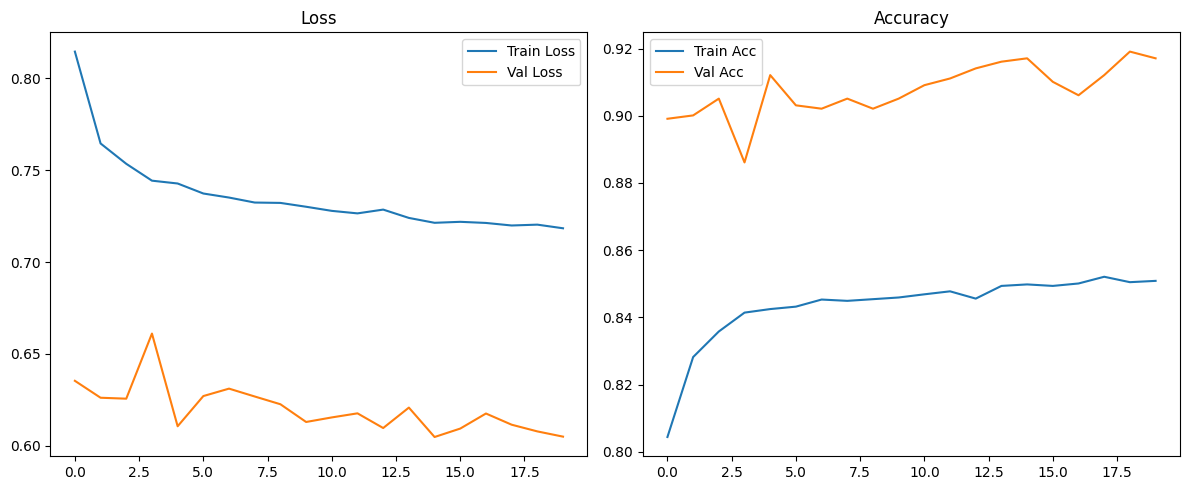

In [19]:
# Lưu mô hình
torch.save(model.state_dict(), "resnet50_finetuned.pth")

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("loss_accuracy_plot.png")
plt.show()

## đánh giá

In [9]:
# Đường dẫn tới dữ liệu
data_dir = "data/images_3"
test_dir = os.path.join(data_dir, "test_images")

# Các biến đổi ảnh
transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomVerticalFlip(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)),  # Xóa ngẫu nhiên vùng ảnh
        transforms.ColorJitter(brightness=0.2),  # Tăng độ tương phản
        transforms.RandomHorizontalFlip(),
      
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Tải dữ liệu

test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Số lớp
num_classes = len(test_dataset.classes)
print(num_classes)

# Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 1. Điều chỉnh Transfer Learning:
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2. Tối ưu kiến trúc lớp cuối:
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),  # Tăng số neuron
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),  # Giảm overfit
    nn.Linear(1024, 512),
    nn.GELU(),  # Activation mạnh hơn ReLU
    nn.Linear(512, num_classes)
)
model = model.to(device)
model.load_state_dict(torch.load("temp/models/resnet50_finetuned.pth",  map_location=device))

label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }

4


In [3]:
# Chạy kiểm thử trên test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [4]:
# Accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 91.86%


In [5]:
# In báo cáo Precision / Recall / F1
class_names = test_dataset.classes
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       250
           1       0.92      0.92      0.92       250
           2       0.88      0.92      0.90       251
           3       0.94      0.91      0.93       244

    accuracy                           0.92       995
   macro avg       0.92      0.92      0.92       995
weighted avg       0.92      0.92      0.92       995



<Figure size 800x600 with 0 Axes>

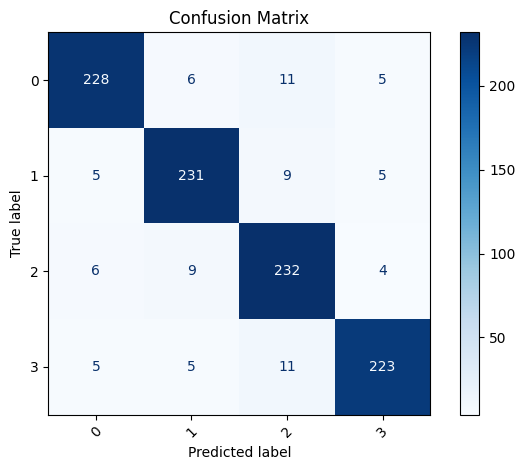

In [6]:
# Vẽ confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

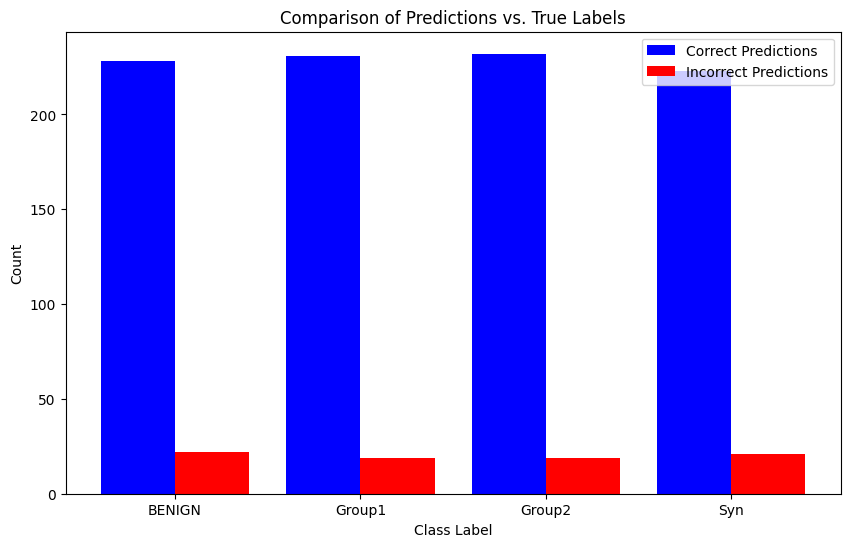

In [15]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": all_labels, "Predicted Label": all_preds})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [26]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [33]:
labels_list = list(label_map.keys())

print(labels_list)
test_data_paths = list(map(lambda x: x, test_dataset.imgs))

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data_paths:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 228, 'Group2': 11, 'Group1': 6, 'Syn': 5}
Label: Group1 {'BENIGN': 5, 'Group1': 231, 'Group2': 9, 'Syn': 5}
Label: Group2 {'BENIGN': 6, 'Group1': 9, 'Group2': 232, 'Syn': 4}
Label: Syn {'BENIGN': 5, 'Syn': 223, 'Group2': 11, 'Group1': 5}
